<a href="https://colab.research.google.com/github/chaehyeonkim-lab/bioinformatics1/blob/main/Binformatics_term_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIN28A가 결합하지만 번역 억제를 받지 않는 ER-associated mRNA 후보 탐색

논문에서의 흐름은 다음과 같다.

LIN28A가 mRNA에 결합한다. 특히 ER/membrane/secretory 관련 mRNA에 많이 결합하는데, 이들은 LIN28A을 knockdown한 경우 ribosome의 density가 증가하는 경향성을 보였다. 따라서 LIN28A는 ER-associated translation을 억제한다.

하지만 여기에는 분명히 예외가 존재한다.

LIN28A가 결합하는 ER-associated mRNA임에도 불구하고, Lin28a knockdown 후 ribosome density가 증가하지 않는 mRNA는 실제로 논문의 Figure 5.B에서도 확인 가능하다.


다음과 같이 그룹을 분류 가능하다.

LIN28A-bound ER mRNA
- CLIP enrichment가 높음
- localization annotation상 ER/membrane/secretory 관련

  1. Suppressed ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density 증가
   - 원래 LIN28A가 번역을 억제했을 가능성이 높음

  2. Escapee ER target
   - LIN28A-bound ER mRNA
   - Lin28a knockdown 후 ribosome density가 증가하지 않음
   - LIN28A가 붙었지만 번역 억제 효과가 뚜렷하지 않음

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/hyeshik/colab-biolab.git
!cd colab-biolab && bash tools/setup.sh
exec(open('colab-biolab/tools/activate_conda.py').read())

Cloning into 'colab-biolab'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 76 (delta 26), reused 59 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 318.16 KiB | 3.74 MiB/s, done.
Resolving deltas: 100% (26/26), done.
./
./root/
./root/.profile
./root/.tmux.conf
./root/.condarc
./root/.bashrc.biolab
./root/.bin.priority/
./root/.bin.priority/pip2
./root/.bin.priority/pip3
./root/.bin.priority/pip
./root/.vimrc
--2026-06-08 14:01:19--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 163179296 (156M) [application/octet-stream]
Saving to: ‘miniconda3.sh’

miniconda3.sh       100%[===================>] 1

In [3]:
!ls -al /content/drive/MyDrive/binfo1-datapack1/

total 7162852
-r-------- 1 root root 1370036258 Apr 27  2023 CLIP-35L33G.bam
-r-------- 1 root root    3118336 Apr 27  2023 CLIP-35L33G.bam.bai
-r-------- 1 root root       7113 May 11  2023 CLIP-let7g.bam
-r-------- 1 root root      14561 May 11  2023 CLIP-let7g-gene.pileup
-r-------- 1 root root    2685065 May 11  2023 CLIP-let7g.pileup
-r-------- 1 root root  883334756 Apr 27  2023 gencode.gtf
-r-------- 1 root root   24065406 Apr 27  2023 read-counts.txt
-r-------- 1 root root        751 Apr 27  2023 read-counts.txt.summary
-r-------- 1 root root 1003658801 Apr 27  2023 RNA-control.bam
-r-------- 1 root root    2276104 Apr 27  2023 RNA-control.bam.bai
-r-------- 1 root root 1260991122 Apr 27  2023 RNA-siLin28a.bam
-r-------- 1 root root    2710744 Apr 27  2023 RNA-siLin28a.bam.bai
-r-------- 1 root root  981684502 Apr 27  2023 RNA-siLuc.bam
-r-------- 1 root root    2606104 Apr 27  2023 RNA-siLuc.bam.bai
-r-------- 1 root root  737352902 Apr 27  2023 RPF-siLin28a.bam
-r-------- 1 r

In [4]:
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
!conda install -y subread

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /root/conda

  added / updated specs:
    - subread


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    certifi-2026.5.20          |     pyhd8ed1ab_0         131 KB  conda-forge
    conda-26.3.2               |  py313h78bf25f_1         1.2 MB  conda-forge
    openssl-3.6.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/binfo1-datapack1")
COUNT_FILE = DATA_DIR / "read-counts.txt"

CLIP_COL = "CLIP-35L33G.bam"
RNA_CONTROL_COL = "RNA-control.bam"
RNA_CTRL_COL = "RNA-siLuc.bam"
RNA_KD_COL = "RNA-siLin28a.bam"
RPF_CTRL_COL = "RPF-siLuc.bam"
RPF_KD_COL = "RPF-siLin28a.bam"

count_cols = [
    CLIP_COL,
    RNA_CONTROL_COL,
    RNA_CTRL_COL,
    RNA_KD_COL,
    RPF_CTRL_COL,
    RPF_KD_COL,
]

RNA_MIN = 30
RPF_MIN = 80
PSEUDO_CPM = 0.1

cnts = pd.read_csv(COUNT_FILE, sep="\t", comment="#")

if "Geneid" in cnts.columns:
    cnts = cnts.set_index("Geneid")

missing_cols = [c for c in count_cols if c not in cnts.columns]
if missing_cols:
    raise ValueError(f"read-counts.txt에 다음 column이 없습니다: {missing_cols}")

cnts[count_cols] = cnts[count_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

library_sizes = cnts[count_cols].sum(axis=0)
print("Library sizes")
display(library_sizes.to_frame(name="total_counts"))

cpm = cnts[count_cols].div(library_sizes, axis=1) * 1_000_000
cpm = cpm.add_suffix("_cpm")

df = pd.concat([cnts, cpm], axis=1)

# 논문 기준에 가깝게 low-count transcript 제거
# RNA는 abundance와 density 계산 모두에 들어가므로 세 RNA library에서 최소 read 수를 둡니다.
# RPF는 최소한 control footprint가 충분해야 density 변화 해석이 안정적입니다.
keep = (
    (df[RNA_CONTROL_COL] >= RNA_MIN) &
    (df[RNA_CTRL_COL] >= RNA_MIN) &
    (df[RNA_KD_COL] >= RNA_MIN) &
    (df[RPF_CTRL_COL] >= RPF_MIN)
)

df = df.loc[keep].copy()

# LIN28A CLIP enrichment
df["clip_log2"] = np.log2(
    (df[f"{CLIP_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CONTROL_COL}_cpm"] + PSEUDO_CPM)
)

# Ribosome density는 RPF/RNA의 log2 ratio로 먼저 계산합니다.
df["rden_siLuc_log2"] = np.log2(
    (df[f"{RPF_CTRL_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CTRL_COL}_cpm"] + PSEUDO_CPM)
)

df["rden_siLin28a_log2"] = np.log2(
    (df[f"{RPF_KD_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_KD_COL}_cpm"] + PSEUDO_CPM)
)

# Lin28a knockdown 후 ribosome density 변화
# 양수: knockdown 후 ribosome density 증가
# 음수: knockdown 후 ribosome density 감소
df["rden_log2"] = df["rden_siLin28a_log2"] - df["rden_siLuc_log2"]

# 기존 코드와의 호환을 위해 ratio scale도 보관
df["rden_siLuc"] = 2 ** df["rden_siLuc_log2"]
df["rden_siLin28a"] = 2 ** df["rden_siLin28a_log2"]

# mRNA abundance 변화
df["rna_change_log2"] = np.log2(
    (df[f"{RNA_KD_COL}_cpm"] + PSEUDO_CPM) /
    (df[f"{RNA_CTRL_COL}_cpm"] + PSEUDO_CPM)
)

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["clip_log2", "rden_log2", "rna_change_log2"])

print("분석에 남은 gene 수:", len(df))

df[
    [
        "Length",
        "clip_log2",
        "rden_siLuc_log2",
        "rden_siLin28a_log2",
        "rden_log2",
        "rna_change_log2",
    ]
].head()

Library sizes


,total_counts
CLIP-35L33G.bam,13630945
RNA-control.bam,5200836
RNA-siLuc.bam,9748787
RNA-siLin28a.bam,12338280
RPF-siLuc.bam,12932285
RPF-siLin28a.bam,10694162


분석에 남은 gene 수: 7987


,Length,clip_log2,rden_siLuc_log2,rden_siLin28a_log2,rden_log2,rna_change_log2
Geneid,,,,,,
ENSMUSG00000033845.14,8487,0.176614,-0.091472,-0.494418,-0.402947,-0.102136
ENSMUSG00000033813.16,3017,-0.268288,-2.274545,-2.488907,-0.214362,-0.402595
ENSMUSG00000033793.13,9746,-0.160983,-0.277670,-0.855732,-0.578061,-0.050419
ENSMUSG00000025907.15,14690,1.049118,-2.248864,-2.179001,0.069862,-0.718631
ENSMUSG00000051285.18,6654,1.338382,-4.080097,-3.291169,0.788928,0.071083


In [8]:
!curl -k -L -o mouselocalization-20210507.txt https://hyeshik.qbio.io/binfo/mouselocalization-20210507.txt

import pandas as pd

local = pd.read_csv('mouselocalization-20210507.txt', sep='\t')
local.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  402k  100  402k    0     0   277k      0  0:00:01  0:00:01 --:--:--  276k


,gene_id,Gene names,type
0,ENSMUSG00000000001,Gnai3,cytoplasm
1,ENSMUSG00000000028,Cdc45 Cdc45l Cdc45l2,nucleus
2,ENSMUSG00000000049,Apoh B2gp1,cytoplasm
3,ENSMUSG00000000058,Cav2,cytoplasm
4,ENSMUSG00000000085,Scmh1,nucleus


In [9]:
from pathlib import Path
import pandas as pd

GTF_FILE = Path("/content/drive/MyDrive/binfo1-datapack1/gencode.gtf")

def parse_gtf_attributes(attr_text):
    result = {}
    for item in attr_text.strip().split(";"):
        item = item.strip()
        if not item:
            continue
        if " " not in item:
            continue
        key, value = item.split(" ", 1)
        result[key] = value.strip().strip('"')
    return result

records = []

with open(GTF_FILE) as f:
    for line in f:
        if line.startswith("#"):
            continue

        parts = line.rstrip("\n").split("\t")
        if len(parts) < 9:
            continue

        feature = parts[2]
        if feature != "gene":
            continue

        attrs = parse_gtf_attributes(parts[8])

        gene_id = attrs.get("gene_id", "")
        gene_id_base = gene_id.split(".")[0]

        records.append(
            {
                "gene_id_base": gene_id_base,
                "gene_name_gtf": attrs.get("gene_name", ""),
                "gene_type": attrs.get("gene_type", attrs.get("gene_biotype", "")),
            }
        )

gtf_gene = pd.DataFrame(records).drop_duplicates("gene_id_base")

print(gtf_gene.shape)
gtf_gene.head()

(55359, 3)


,gene_id_base,gene_name_gtf,gene_type
0,ENSMUSG00000102693,4933401J01Rik,TEC
1,ENSMUSG00000064842,Gm26206,snRNA
2,ENSMUSG00000051951,Xkr4,protein_coding
3,ENSMUSG00000102851,Gm18956,processed_pseudogene
4,ENSMUSG00000103377,Gm37180,TEC


In [10]:
# df: read-counts.txt에서 계산한 expression / CLIP / RPF 지표
# local: mouselocalization-20210507.txt
# gtf_gene: gencode.gtf에서 추출한 gene_name_gtf, gene_type

merged = df.copy().reset_index()

# reset_index 후 첫 번째 column이 gene id입니다.
merged = merged.rename(columns={merged.columns[0]: "gene_id_count"})

# version 제거: ENSMUSG00000000001.4 -> ENSMUSG00000000001
merged["gene_id_base"] = (
    merged["gene_id_count"]
    .astype(str)
    .str.replace(r"\.\d+$", "", regex=True)
)

# GTF annotation merge
merged = merged.merge(gtf_gene, on="gene_id_base", how="left")

# localization annotation 정리
local2 = local.copy()

local2["gene_id_base"] = (
    local2["gene_id"]
    .astype(str)
    .str.replace(r"\.\d+$", "", regex=True)
)

local2 = (
    local2
    .groupby("gene_id_base", as_index=False)
    .agg(
        {
            "Gene names": lambda x: "; ".join(sorted(set(x.dropna().astype(str)))),
            "type": lambda x: "; ".join(sorted(set(x.dropna().astype(str)))),
        }
    )
)

merged = merged.merge(local2, on="gene_id_base", how="left")

# gene symbol은 GTF를 우선 사용하고, 없으면 localization 파일의 첫 번째 이름 사용
merged["gene_symbol"] = merged["gene_name_gtf"]

fallback_symbol = (
    merged["Gene names"]
    .fillna("")
    .astype(str)
    .str.split(r"\s+|;")
    .str[0]
)

merged.loc[merged["gene_symbol"].isna() | (merged["gene_symbol"] == ""), "gene_symbol"] = fallback_symbol

print("전체 gene 수:", len(merged))
print("GTF gene_name이 붙은 gene 수:", merged["gene_name_gtf"].notna().sum())
print("localization annotation이 붙은 gene 수:", merged["type"].notna().sum())
print("localization annotation이 없는 gene 수:", merged["type"].isna().sum())

merged[
    [
        "gene_id_count",
        "gene_symbol",
        "gene_type",
        "Gene names",
        "type",
        "clip_log2",
        "rden_log2",
        "rna_change_log2",
    ]
].head()

전체 gene 수: 7987
GTF gene_name이 붙은 gene 수: 7987
localization annotation이 붙은 gene 수: 4492
localization annotation이 없는 gene 수: 3495


,gene_id_count,gene_symbol,gene_type,Gene names,type,clip_log2,rden_log2,rna_change_log2
0,ENSMUSG00000033845.14,Mrpl15,protein_coding,NaN,NaN,0.176614,-0.402947,-0.102136
1,ENSMUSG00000033813.16,Tcea1,protein_coding,NaN,NaN,-0.268288,-0.214362,-0.402595
2,ENSMUSG00000033793.13,Atp6v1h,protein_coding,NaN,NaN,-0.160983,-0.578061,-0.050419
3,ENSMUSG00000025907.15,Rb1cc1,protein_coding,Rb1cc1 Cc1 Kiaa0203,nucleus,1.049118,0.069862,-0.718631
4,ENSMUSG00000051285.18,Pcmtd1,protein_coding,Pcmtd1,cytoplasm,1.338382,0.788928,0.071083


In [11]:
# 현재 mouselocalization 파일의 type은 주로
# 'cytoplasm', 'nucleus', 'integral membrane' 수준입니다.
# 따라서 이 분석에서 ER-associated를 직접 부르는 대신
# integral membrane을 ER-associated translation의 proxy로 사용합니다.

merged['er_proxy'] = (
    merged['type']
    .fillna('')
    .astype(str)
    .str.contains(r'\bintegral membrane\b', case=False, regex=True)
)

print(merged['er_proxy'].value_counts())

merged.loc[
    merged['er_proxy'],
    ['gene_id_count', 'Gene names', 'type', 'clip_log2', 'rden_log2', 'rna_change_log2']
].head(20)

print(merged['er_proxy'].value_counts())

merged.loc[
    merged['er_proxy'],
    ['gene_id_count', 'Gene names', 'type']
].head(20)

er_proxy
False    6934
True     1053
Name: count, dtype: int64
er_proxy
False    6934
True     1053
Name: count, dtype: int64


,gene_id_count,Gene names,type
23,ENSMUSG00000025931.16,Paqr8 Mprb,integral membrane
33,ENSMUSG00000073725.9,Lmbrd1,integral membrane
38,ENSMUSG00000026131.21,Dst Bpag1 Macf2,integral membrane
41,ENSMUSG00000037503.13,Fam168b Kiaa4042,integral membrane
42,ENSMUSG00000026123.12,Plekhb2 Evt2,integral membrane
43,ENSMUSG00000045216.8,Hs6st1,integral membrane
46,ENSMUSG00000001143.14,Lman2l Vipl,integral membrane
47,ENSMUSG00000037408.11,Cnnm4 Acdp4 Kiaa1592,integral membrane
48,ENSMUSG00000001138.14,Cnnm3 Acdp3,integral membrane
52,ENSMUSG00000026116.12,Tmem131 D1Bwg0491e Kiaa0257 Rw1,integral membrane


In [12]:
import numpy as np

# -----------------------------
# Thresholds
# -----------------------------
CLIP_Q = 0.90                 # 현재 노트북 기준 유지: 상위 10%
RNA_CHANGE_MIN = -0.5         # mRNA abundance가 0.71배 이상 유지
SUPPRESSED_CUTOFF = 0.5       # log2 scale; 약 1.41배 이상 ribosome density 증가
ESCAPEE_CUTOFF = 0.0          # 증가 없음

# 분석 대상으로 삼을 gene
# protein_coding 정보가 없을 수도 있으므로, gene_type이 비어 있으면 일단 포함합니다.
analysis_base = (
    merged["clip_log2"].notna() &
    merged["rden_log2"].notna() &
    merged["rna_change_log2"].notna()
)

if "gene_type" in merged.columns:
    analysis_base = analysis_base & (
        merged["gene_type"].isna() |
        (merged["gene_type"] == "") |
        (merged["gene_type"] == "protein_coding")
    )

# histone mRNA는 poly(A) 문제 때문에 원 논문에서도 주의 대상입니다.
# gene_symbol이 있는 경우 Hist로 시작하는 gene을 제외합니다.
not_histone = ~merged["gene_symbol"].fillna("").str.startswith("Hist")
analysis_base = analysis_base & not_histone

clip_cutoff = merged.loc[analysis_base, "clip_log2"].quantile(CLIP_Q)

print("LIN28A strong binding cutoff:", clip_cutoff)

strong_binding = merged["clip_log2"] >= clip_cutoff
er_proxy = merged["er_proxy"]
rna_not_decreased = merged["rna_change_log2"] >= RNA_CHANGE_MIN

translation_derepressed = merged["rden_log2"] >= SUPPRESSED_CUTOFF
translation_escapee = merged["rden_log2"] <= ESCAPEE_CUTOFF

candidate_base = analysis_base & strong_binding & er_proxy & rna_not_decreased

merged["target_class"] = "Other"

merged.loc[
    candidate_base,
    "target_class"
] = "LIN28A-bound ER-proxy intermediate"

merged.loc[
    candidate_base & translation_derepressed,
    "target_class"
] = "Suppressed-like ER target"

merged.loc[
    candidate_base & translation_escapee,
    "target_class"
] = "Escapee ER target"

merged["target_class"].value_counts()

LIN28A strong binding cutoff: 0.9805813164977287


,count
target_class,
Other,7735
Suppressed-like ER target,157
LIN28A-bound ER-proxy intermediate,86
Escapee ER target,9


In [13]:
def classify_with_thresholds(
    data,
    clip_q=0.90,
    rna_change_min=-0.5,
    suppressed_cutoff=0.5,
    escapee_cutoff=0.0,
):
    base = (
        data["clip_log2"].notna() &
        data["rden_log2"].notna() &
        data["rna_change_log2"].notna()
    )

    if "gene_type" in data.columns:
        base = base & (
            data["gene_type"].isna() |
            (data["gene_type"] == "") |
            (data["gene_type"] == "protein_coding")
        )

    base = base & ~data["gene_symbol"].fillna("").str.startswith("Hist")

    cutoff = data.loc[base, "clip_log2"].quantile(clip_q)

    strong = data["clip_log2"] >= cutoff
    er = data["er_proxy"]
    rna_ok = data["rna_change_log2"] >= rna_change_min

    cand = base & strong & er & rna_ok
    suppressed = cand & (data["rden_log2"] >= suppressed_cutoff)
    escapee = cand & (data["rden_log2"] <= escapee_cutoff)
    intermediate = cand & ~(suppressed | escapee)

    return {
        "clip_q": clip_q,
        "clip_cutoff": cutoff,
        "candidate_base": int(cand.sum()),
        "suppressed": int(suppressed.sum()),
        "escapee": int(escapee.sum()),
        "intermediate": int(intermediate.sum()),
    }

sensitivity = pd.DataFrame(
    [
        classify_with_thresholds(merged, clip_q=q)
        for q in [0.80, 0.90, 0.95]
    ]
)

sensitivity

,clip_q,clip_cutoff,candidate_base,suppressed,escapee,intermediate
0,0.80,0.398461,430,233,26,171
1,0.90,0.980581,252,157,9,86
2,0.95,1.401439,141,98,4,39


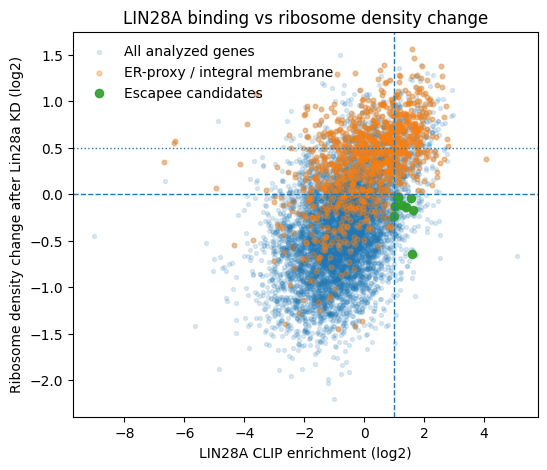

All genes Pearson r, p: PearsonRResult(statistic=np.float64(0.4878989084908113), pvalue=np.float64(0.0))
All genes Spearman rho, p: SignificanceResult(statistic=np.float64(0.4808637376643336), pvalue=np.float64(0.0))


In [14]:
import matplotlib.pyplot as plt
from scipy import stats

plot_df = merged.loc[analysis_base].copy()

fig, ax = plt.subplots(figsize=(6, 5))

# 전체 gene
ax.scatter(
    plot_df["clip_log2"],
    plot_df["rden_log2"],
    s=8,
    alpha=0.15,
    label="All analyzed genes",
)

# ER proxy gene
er_df = plot_df[plot_df["er_proxy"]]
ax.scatter(
    er_df["clip_log2"],
    er_df["rden_log2"],
    s=12,
    alpha=0.35,
    label="ER-proxy / integral membrane",
)

# Escapee 후보
escapee_df = plot_df[plot_df["target_class"] == "Escapee ER target"]
ax.scatter(
    escapee_df["clip_log2"],
    escapee_df["rden_log2"],
    s=35,
    alpha=0.9,
    label="Escapee candidates",
)

ax.axvline(clip_cutoff, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(SUPPRESSED_CUTOFF, linestyle=":", linewidth=1)

ax.set_xlabel("LIN28A CLIP enrichment (log2)")
ax.set_ylabel("Ribosome density change after Lin28a KD (log2)")
ax.set_title("LIN28A binding vs ribosome density change")
ax.legend(frameon=False)

plt.show()

pearson_all = stats.pearsonr(plot_df["clip_log2"], plot_df["rden_log2"])
spearman_all = stats.spearmanr(plot_df["clip_log2"], plot_df["rden_log2"])

print("All genes Pearson r, p:", pearson_all)
print("All genes Spearman rho, p:", spearman_all)

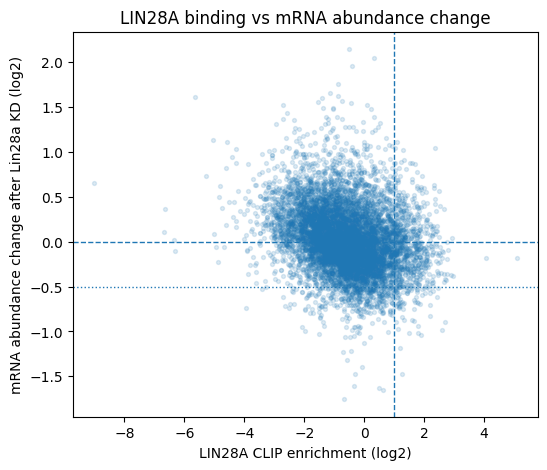

CLIP vs RNA change Pearson r, p: PearsonRResult(statistic=np.float64(-0.2716938280225777), pvalue=np.float64(1.0088954694998892e-132))
CLIP vs RNA change Spearman rho, p: SignificanceResult(statistic=np.float64(-0.2949602499622127), pvalue=np.float64(3.686125606584136e-157))


In [15]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    plot_df["clip_log2"],
    plot_df["rna_change_log2"],
    s=8,
    alpha=0.15,
)

ax.axvline(clip_cutoff, linestyle="--", linewidth=1)
ax.axhline(0, linestyle="--", linewidth=1)
ax.axhline(RNA_CHANGE_MIN, linestyle=":", linewidth=1)

ax.set_xlabel("LIN28A CLIP enrichment (log2)")
ax.set_ylabel("mRNA abundance change after Lin28a KD (log2)")
ax.set_title("LIN28A binding vs mRNA abundance change")

plt.show()

pearson_rna = stats.pearsonr(plot_df["clip_log2"], plot_df["rna_change_log2"])
spearman_rna = stats.spearmanr(plot_df["clip_log2"], plot_df["rna_change_log2"])

print("CLIP vs RNA change Pearson r, p:", pearson_rna)
print("CLIP vs RNA change Spearman rho, p:", spearman_rna)

In [16]:
out_cols = [
    "gene_id_count",
    "gene_id_base",
    "gene_symbol",
    "gene_type",
    "Gene names",
    "type",
    "Length",
    "clip_log2",
    "rden_siLuc_log2",
    "rden_siLin28a_log2",
    "rden_log2",
    "rna_change_log2",
    "target_class",
]

available_out_cols = [c for c in out_cols if c in merged.columns]

escapee_candidates = (
    merged
    .loc[merged["target_class"] == "Escapee ER target", available_out_cols]
    .sort_values(["clip_log2", "rden_log2"], ascending=[False, True])
)

suppressed_targets = (
    merged
    .loc[merged["target_class"] == "Suppressed-like ER target", available_out_cols]
    .sort_values(["rden_log2", "clip_log2"], ascending=[False, False])
)

display(escapee_candidates.head(30))
display(suppressed_targets.head(30))

escapee_candidates.to_csv("escapee_er_proxy_candidates.tsv", sep="\t", index=False)
suppressed_targets.to_csv("suppressed_like_er_targets.tsv", sep="\t", index=False)

print("Saved: escapee_er_proxy_candidates.tsv")
print("Saved: suppressed_like_er_targets.tsv")

,gene_id_count,gene_id_base,gene_symbol,gene_type,Gene names,type,Length,clip_log2,rden_siLuc_log2,rden_siLin28a_log2,rden_log2,rna_change_log2,target_class
2694,ENSMUSG00000030286.7,ENSMUSG00000030286,Emc3,protein_coding,Emc3 Tmem111,integral membrane,3361,1.645418,0.010852,-0.156706,-0.167559,0.241262,Escapee ER target
4581,ENSMUSG00000020189.16,ENSMUSG00000020189,Osbpl8,protein_coding,Osbpl8 Kiaa1451 Orp8,integral membrane,9600,1.584574,-1.397737,-2.043035,-0.645298,0.472904,Escapee ER target
5103,ENSMUSG00000020521.8,ENSMUSG00000020521,Rnft1,protein_coding,Rnft1,integral membrane,4719,1.563188,-0.042662,-0.078813,-0.036152,0.296524,Escapee ER target
1180,ENSMUSG00000027784.11,ENSMUSG00000027784,Ppm1l,protein_coding,Ppm1l Kiaa4175,integral membrane,10496,1.408320,-0.657352,-0.794633,-0.137281,0.118519,Escapee ER target
5559,ENSMUSG00000063450.15,ENSMUSG00000063450,Syne2,protein_coding,Syne2,integral membrane,26726,1.271991,-1.976459,-2.088399,-0.111941,-0.063390,Escapee ER target
6018,ENSMUSG00000021870.18,ENSMUSG00000021870,Slmap,protein_coding,Slmap Kiaa1601 Slap,integral membrane,8054,1.124750,-2.177231,-2.209273,-0.032043,0.127191,Escapee ER target
5500,ENSMUSG00000044408.8,ENSMUSG00000044408,Sptssa,protein_coding,Sptssa Ssspta,integral membrane,1518,1.040863,-0.787544,-0.914447,-0.126903,-0.037291,Escapee ER target
722,ENSMUSG00000027253.16,ENSMUSG00000027253,Lrp4,protein_coding,Lrp4 Kiaa0816,integral membrane,10504,1.025777,0.011090,-0.118114,-0.129203,0.626850,Escapee ER target
7169,ENSMUSG00000024091.10,ENSMUSG00000024091,Vapa,protein_coding,Vapa Vap33,integral membrane,3492,0.997857,0.236443,0.004430,-0.232014,-0.200952,Escapee ER target


,gene_id_count,gene_id_base,gene_symbol,gene_type,Gene names,type,Length,clip_log2,rden_siLuc_log2,rden_siLin28a_log2,rden_log2,rna_change_log2,target_class
5540,ENSMUSG00000021072.13,ENSMUSG00000021072,Tmx1,protein_coding,Tmx1 Txndc Txndc1,integral membrane,3299,2.577291,-0.825391,0.550990,1.376381,-0.350770,Suppressed-like ER target
6080,ENSMUSG00000036242.16,ENSMUSG00000036242,Armh4,protein_coding,Armh4,integral membrane,9271,1.612724,1.324038,2.592820,1.268781,-0.495057,Suppressed-like ER target
4334,ENSMUSG00000019838.12,ENSMUSG00000019838,Slc16a10,protein_coding,Slc16a10 Mct10 Tat1,integral membrane,7356,1.175557,0.019521,1.229522,1.210000,-0.472728,Suppressed-like ER target
1453,ENSMUSG00000066324.3,ENSMUSG00000066324,Bpnt2,protein_coding,Bpnt2 Impa3 Impad1,integral membrane,6543,2.593505,-2.244298,-1.089230,1.155068,-0.179259,Suppressed-like ER target
6494,ENSMUSG00000075470.3,ENSMUSG00000075470,Alg10b,protein_coding,Alg10b,integral membrane,6644,1.715857,-2.702170,-1.551665,1.150505,-0.298119,Suppressed-like ER target
5903,ENSMUSG00000021687.15,ENSMUSG00000021687,Scamp1,protein_coding,Scamp1,integral membrane,4582,1.892717,-0.453716,0.685032,1.138749,-0.315773,Suppressed-like ER target
1465,ENSMUSG00000045205.17,ENSMUSG00000045205,Dpy19l4,protein_coding,Dpy19l4 Gm1023,integral membrane,8101,1.842103,-0.569449,0.568006,1.137455,-0.166794,Suppressed-like ER target
327,ENSMUSG00000026469.15,ENSMUSG00000026469,Xpr1,protein_coding,Xpr1 Syg1,integral membrane,17880,1.347722,-2.126072,-1.000269,1.125803,-0.117892,Suppressed-like ER target
4343,ENSMUSG00000019818.16,ENSMUSG00000019818,Cd164,protein_coding,Cd164,integral membrane,4449,1.840171,0.249640,1.353081,1.103441,-0.201414,Suppressed-like ER target
7082,ENSMUSG00000023961.17,ENSMUSG00000023961,Enpp4,protein_coding,Enpp4 Kiaa0879,integral membrane,4560,1.754948,-0.214636,0.887320,1.101957,0.077726,Suppressed-like ER target


Saved: escapee_er_proxy_candidates.tsv
Saved: suppressed_like_er_targets.tsv


In [17]:
# g:Profiler 또는 Enrichr 등에 넣기 위한 gene symbol list
# background는 전체 genome이 아니라, 이번 분석에서 실제로 test 가능한 gene으로 잡습니다.

background_df = merged.loc[analysis_base].copy()

background_symbols = (
    background_df["gene_symbol"]
    .dropna()
    .astype(str)
    .loc[lambda s: s != ""]
    .drop_duplicates()
)

escapee_symbols = (
    escapee_candidates["gene_symbol"]
    .dropna()
    .astype(str)
    .loc[lambda s: s != ""]
    .drop_duplicates()
)

suppressed_symbols = (
    suppressed_targets["gene_symbol"]
    .dropna()
    .astype(str)
    .loc[lambda s: s != ""]
    .drop_duplicates()
)

background_symbols.to_csv("background_tested_gene_symbols.txt", index=False, header=False)
escapee_symbols.to_csv("escapee_gene_symbols.txt", index=False, header=False)
suppressed_symbols.to_csv("suppressed_gene_symbols.txt", index=False, header=False)

print("background:", len(background_symbols))
print("escapee:", len(escapee_symbols))
print("suppressed:", len(suppressed_symbols))

background: 7840
escapee: 9
suppressed: 157
